In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import requests

In [3]:
df = pd.read_csv('drive/MyDrive/GIZ_Irradiation_Project/Working Folder/models/CBE_Data/CBE_Nigeria.csv')

In [4]:
df.head(10)

,MEASURE_DATE,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE
0,2024-09-18,4752.722000,Nigeria,6.448858,7.392609
1,2024-09-22,5443.410000,Nigeria,6.448858,7.392609
2,2024-09-25,4191.169000,Nigeria,6.448858,7.392609
3,2022-02-23,5384.955394,Nigeria,9.076439,7.425385
4,2021-07-17,4857.890352,Nigeria,9.076439,7.425385
5,2021-09-22,2290.865857,Nigeria,9.076439,7.425385
6,2024-06-17,6185.613000,Nigeria,6.448858,7.392609
7,2021-07-23,2380.467570,Nigeria,9.076439,7.425385
8,2023-01-02,5426.296000,Nigeria,9.076439,7.425385
9,2020-11-07,6455.121584,Nigeria,9.076439,7.425385


In [5]:
df.tail(10)

,MEASURE_DATE,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE
2392,2024-10-13,5613.556,Nigeria,9.076439,7.425385
2393,2024-10-13,2621.799,Nigeria,6.448858,7.392609
2394,2024-10-16,5640.367,Nigeria,9.076439,7.425385
2395,2024-10-16,2347.304,Nigeria,6.448858,7.392609
2396,2024-10-21,2835.402,Nigeria,6.448858,7.392609
2397,2024-10-22,1531.990,Nigeria,6.448858,7.392609
2398,2024-11-06,6419.752,Nigeria,9.076439,7.425385
2399,2024-11-06,5402.671,Nigeria,6.448858,7.392609
2400,2024-11-13,6503.395,Nigeria,9.076439,7.425385
2401,2024-11-13,7048.654,Nigeria,6.448858,7.392609


In [6]:
df['MEASURE_DATE'] = pd.to_datetime(df['MEASURE_DATE'])
df = df.set_index('MEASURE_DATE')
df = df.sort_index()

df.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE
MEASURE_DATE,,,,
2020-02-19,0.0,Nigeria,9.076439,7.425385
2020-02-20,0.0,Nigeria,9.076439,7.425385
2020-02-21,0.0,Nigeria,9.076439,7.425385
2020-02-22,0.0,Nigeria,9.076439,7.425385
2020-02-23,0.0,Nigeria,9.076439,7.425385


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2402 entries, 2020-02-19 to 2024-11-25
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MEASURE_VALUE   2402 non-null   float64
 1   SITE_COUNTRY    2402 non-null   object 
 2   SITE_LATITUDE   2402 non-null   float64
 3   SITE_LONGITUDE  2402 non-null   float64
dtypes: float64(3), object(1)
memory usage: 93.8+ KB


In [8]:
def add_unique_location_column(df, lat_col='latitude', lon_col='longitude'):
    """
    Adds a new column to the DataFrame with unique location names (e.g., 'Location 1', 'Location 2')
    based on latitude and longitude values.

    Args:
        df (pd.DataFrame): The DataFrame containing latitude and longitude columns.
        lat_col (str): Name of the column for latitude. Default is 'latitude'.
        lon_col (str): Name of the column for longitude. Default is 'longitude'.

    Returns:
        pd.DataFrame: The DataFrame with a new column 'location'.
    """
    # Create a unique identifier for each latitude-longitude pair
    unique_coords = {}
    location_counter = 1

    def get_location(lat, lon):
        nonlocal location_counter
        coord = (lat, lon)
        if coord not in unique_coords:
            unique_coords[coord] = f"Location {location_counter}"
            location_counter += 1
        return unique_coords[coord]

    df['location'] = df.apply(lambda row: get_location(row[lat_col], row[lon_col]), axis=1)
    return df

In [9]:
df_loc = add_unique_location_column(df, lat_col='SITE_LATITUDE', lon_col='SITE_LONGITUDE')
df_loc.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,location
MEASURE_DATE,,,,,
2020-02-19,0.0,Nigeria,9.076439,7.425385,Location 1
2020-02-20,0.0,Nigeria,9.076439,7.425385,Location 1
2020-02-21,0.0,Nigeria,9.076439,7.425385,Location 1
2020-02-22,0.0,Nigeria,9.076439,7.425385,Location 1
2020-02-23,0.0,Nigeria,9.076439,7.425385,Location 1


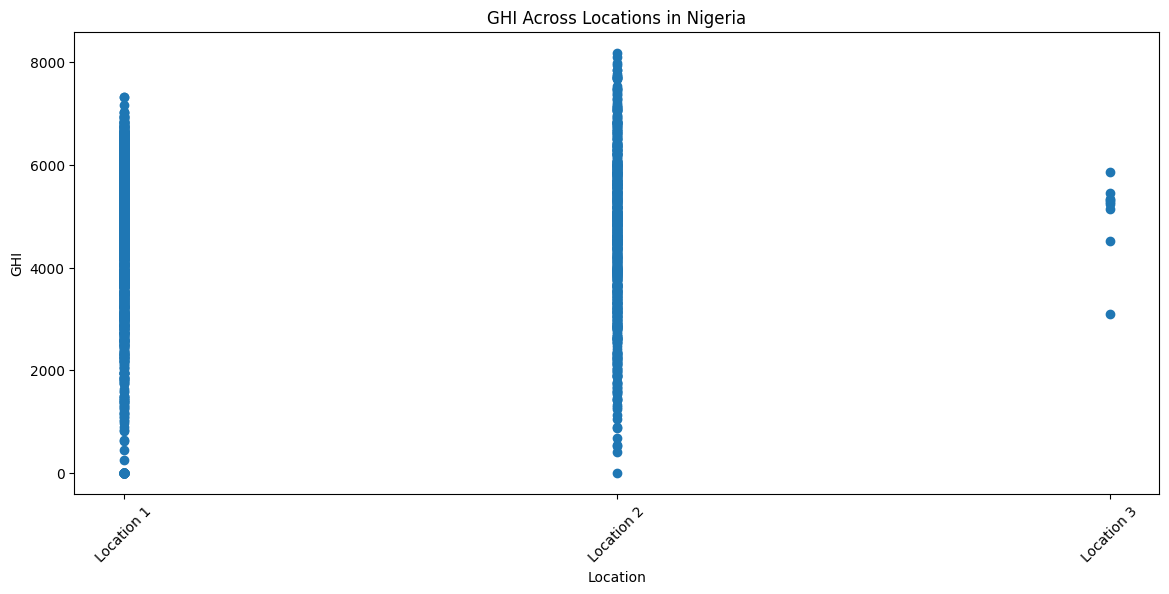

In [10]:
plt.figure(figsize=(14, 6))
plt.scatter(df['location'], df['MEASURE_VALUE'])
plt.xlabel('Location')
plt.ylabel('GHI')
plt.title('GHI Across Locations in Nigeria')
plt.xticks(rotation=45)
plt.show()

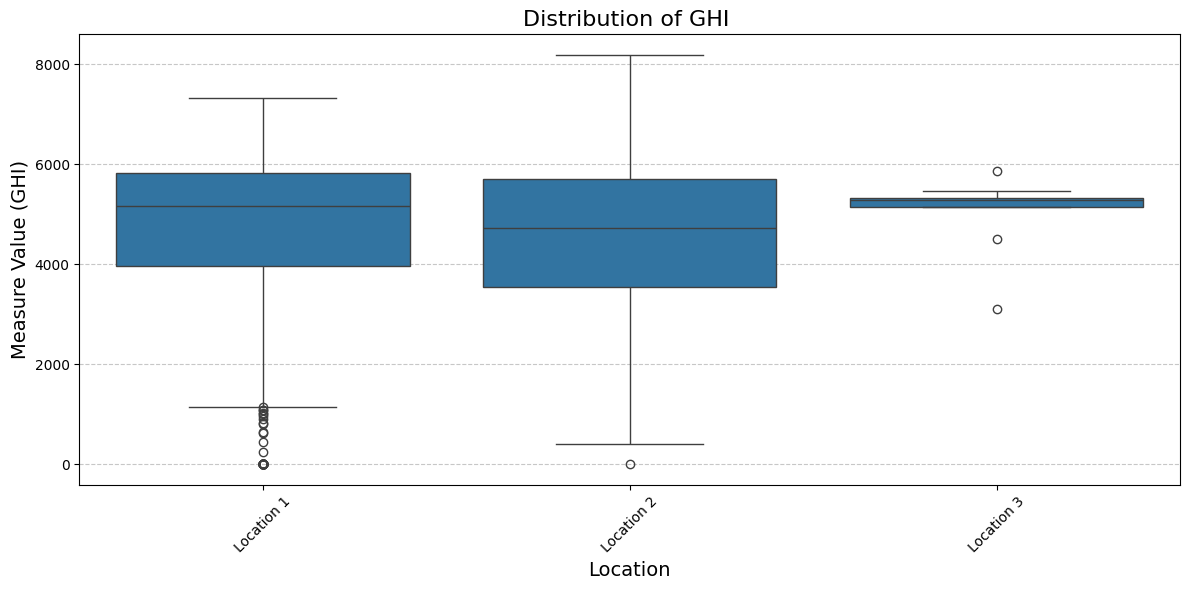

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='MEASURE_VALUE', data=df)

# Add labels and titles
plt.xlabel('Location', fontsize=14)
plt.ylabel('Measure Value (GHI)', fontsize=14)
plt.title('Distribution of GHI ', fontsize=16)
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


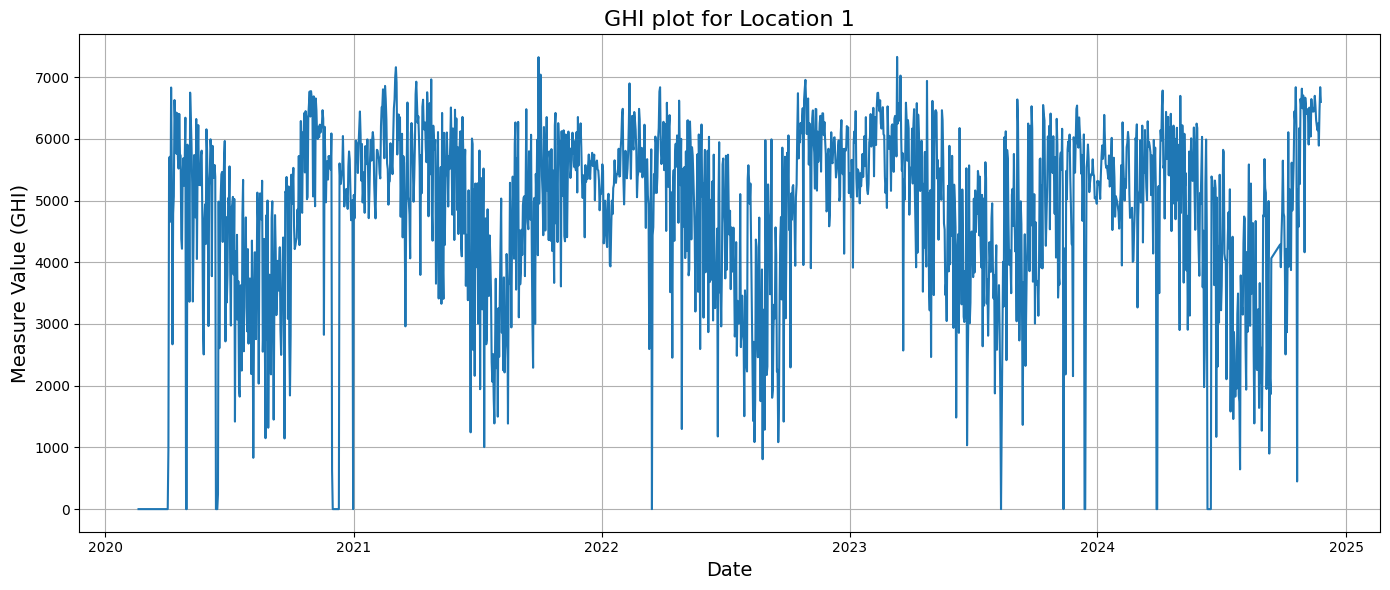

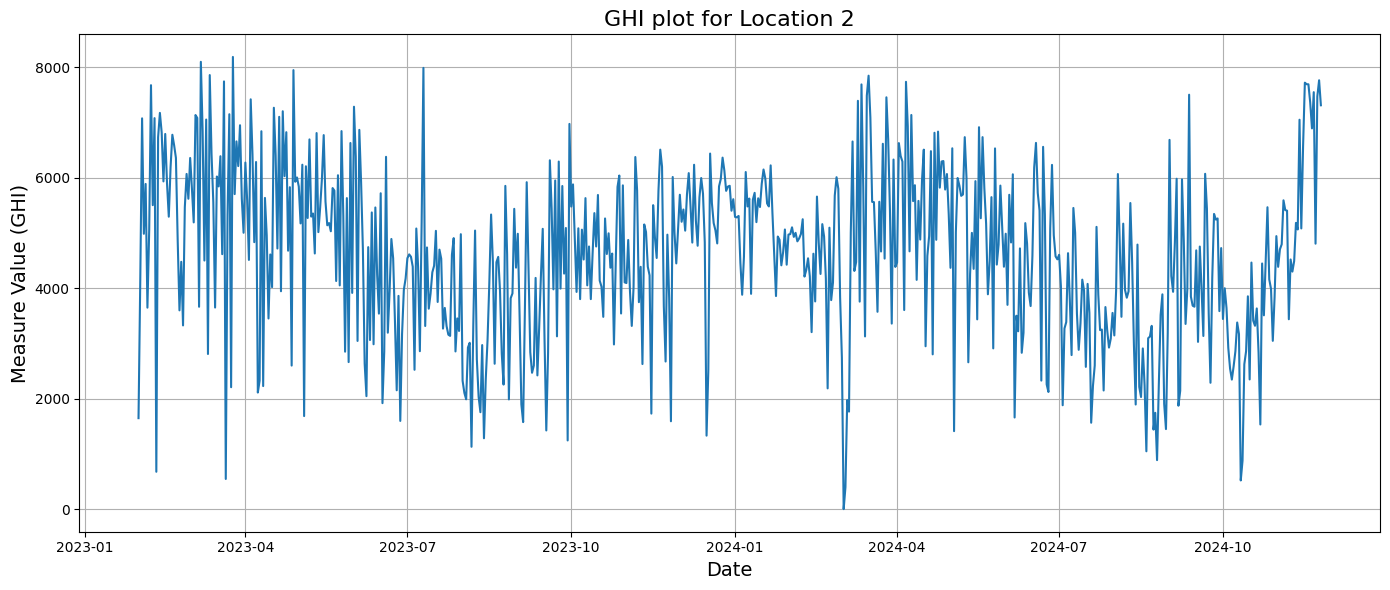

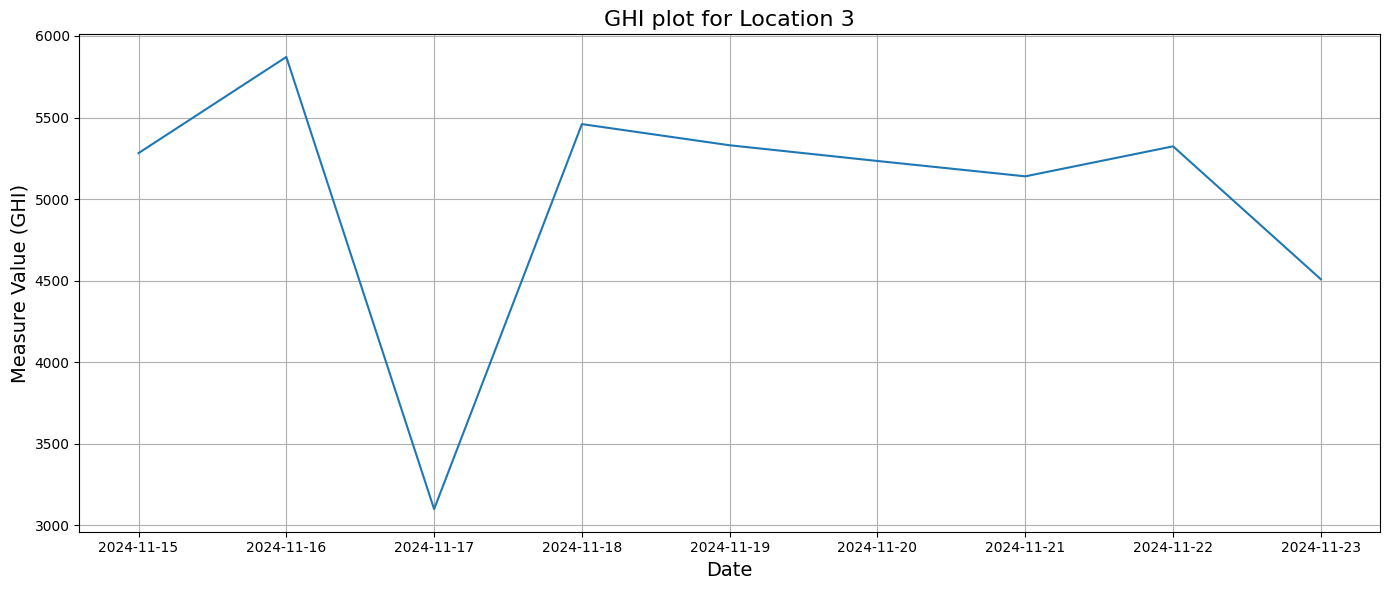

In [11]:
locations = df['location'].unique()


for location in locations:
    # Filter data for the current location
    location_data = df[df['location'] == location]

    # Create a new figure for each location
    plt.figure(figsize=(14, 6))
    plt.plot(location_data.index, location_data['MEASURE_VALUE'])

    # Add labels and titles
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Measure Value (GHI)', fontsize=14)
    plt.title(f'GHI plot for {location}', fontsize=16)
    plt.grid(True)
    plt.tight_layout()

    # Show the plot
    plt.show()

##Altitude

In [12]:
def get_elevation(lat, lon):
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    response = requests.get(url)
    if response.status_code == 200:
        result = response.json()['results'][0]
        return result['elevation']  # Elevation in meters
    else:
        return None

cache = {}

def get_elevation_cached(lat, lon):
    coord = (lat, lon)
    if coord not in cache:
        cache[coord] = get_elevation(lat, lon)
    return cache[coord]

In [13]:
df['elevation'] = df.apply(lambda row: get_elevation_cached(row['SITE_LATITUDE'], row['SITE_LONGITUDE']), axis=1)
df.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,location,elevation
MEASURE_DATE,,,,,,
2020-02-19,0.0,Nigeria,9.076439,7.425385,Location 1,448.0
2020-02-20,0.0,Nigeria,9.076439,7.425385,Location 1,448.0
2020-02-21,0.0,Nigeria,9.076439,7.425385,Location 1,448.0
2020-02-22,0.0,Nigeria,9.076439,7.425385,Location 1,448.0
2020-02-23,0.0,Nigeria,9.076439,7.425385,Location 1,448.0


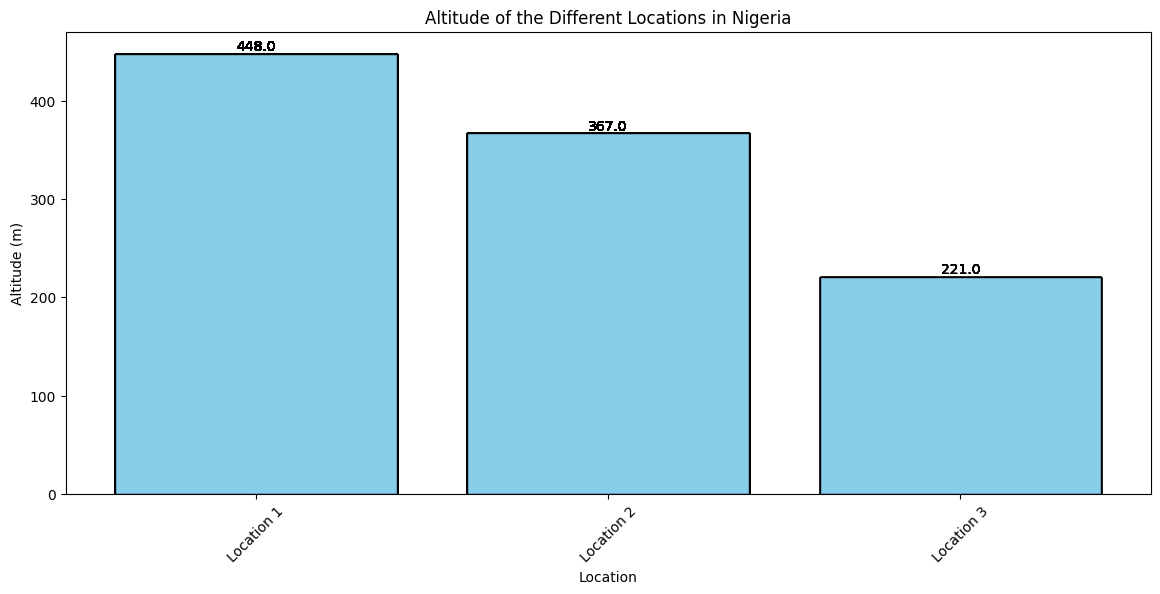

In [14]:
plt.figure(figsize=(14, 6))
bars = plt.bar(df['location'], df['elevation'], color='skyblue', edgecolor='black')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}',
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Location')
plt.ylabel('Altitude (m)')
plt.title('Altitude of the Different Locations in Nigeria')
plt.xticks(rotation=45)
plt.show()